# Descriptive Content as a Predictor for Semantic Shift Trajectory 

This notebook contains exploratory work on the neighborhood diffuseness measures TN, concentration, step/radius/ratio. While the candidate words and trends initially looked very positive, they didn't survive the time-shuffled corpus. 

TN was taken from Schulte im Walde and Frassinelli's 2022 paper about distributional measures. Chaining was taken by Ramiro et al.'s "Algorithms in the historical emergence of word senses" (2018); the rest of the measures were inspired by the paper. 

## Setup

In [11]:
from driftcache import Space

VECTORS = "./vectors/5sub/sgns.words"
VOCAB = "./vectors/5sub/counts.words.vocab"

YEARS = range(2012, 2019)

sp = Space(VECTORS)

In [12]:
counts = sp.counts(VOCAB)   # {word: {year: count}}

In [13]:
counts

defaultdict(dict,
            {'to': {2015: 135337416,
              2014: 134767316,
              2016: 132130058,
              2017: 118447810,
              2013: 113432456,
              2018: 110265587,
              2012: 47547674},
             'the': {2014: 122974955,
              2013: 110293258,
              2015: 109317801,
              2016: 103354204,
              2017: 87895757,
              2018: 78054040,
              2012: 43536220},
             'and': {2015: 113189218,
              2014: 112872732,
              2016: 108920941,
              2017: 98039146,
              2013: 93511035,
              2018: 92958675,
              2012: 38569364},
             'i': {2014: 107399061,
              2015: 99249423,
              2013: 91430200,
              2016: 87935155,
              2018: 81993682,
              2017: 81504526,
              2012: 38215122},
             'a': {2014: 101749894,
              2015: 94580693,
              2013: 90405347,
   

In [14]:
threshold = 150*8

best_year = {}
for word in counts:
    best_year[word] = next(
        (year for year in sorted(counts[word]) if counts[word][year] > threshold),
        None
    )

In [15]:
best_year["fam"]

2012

In [16]:
year_mat = sp.mat        
year_words = sp.words    
year_index = sp.index

In [17]:
class _Neighbors:
    def __init__(self, sp, year):
        self._sp, self._y = sp, year

    def __getitem__(self, word):
        return self._sp.neighbors(self._y, word)

    def __contains__(self, word):
        return word in self._sp.index[self._y]

    def keys(self):
        return iter(self._sp.words[self._y])

    def items(self):
        for w in self._sp.words[self._y]:
            yield w, self._sp.neighbors(self._y, w)


nearest_neighbors = {y: _Neighbors(sp, y) for y in YEARS}

In [18]:
print(nearest_neighbors[2012]["fam"])

[('family', 0.7042898535728455), ('thanksgiving', 0.610325813293457), ('cousins', 0.588330864906311), ('bday', 0.5870862603187561), ('relatives', 0.5854615569114685), ('grandparents', 0.584242582321167), ('flatmates', 0.5830857753753662), ('holidays', 0.5699122548103333), ('missus', 0.5692473649978638), ('celebrations', 0.56788569688797), ('aunts', 0.5648673176765442), ('waldorf', 0.5618183612823486), ('inlaws', 0.5605840086936951), ("family's", 0.5592190623283386), ('grandpa', 0.5570664405822754), ('hubby', 0.5567858219146729), ('mas', 0.5547812581062317), ('christmas', 0.5528838634490967), ('nieces', 0.5518621802330017), ('grandma', 0.5492753982543945), ('rl', 0.5465186238288879), ('hometown', 0.5437514185905457), ('mum', 0.5413945317268372), ('uncles', 0.5403158664703369), ('clan', 0.5400839447975159)]


In [19]:
print(nearest_neighbors[2018]["fam"])

[('homie', 0.8994911313056946), ('bro', 0.8944010138511658), ('bruv', 0.8471296429634094), ('dood', 0.8209227323532104), ('ayy', 0.8099871277809143), ('aight', 0.8078922033309937), ('aye', 0.8046605587005615), ('bruh', 0.8017076849937439), ('bby', 0.8006547689437866), ('vro', 0.7986037731170654), ('fellas', 0.7961007952690125), ('broski', 0.7932378649711609), ('boyo', 0.7819625735282898), ('bb', 0.7815033197402954), ('ayyy', 0.7786298394203186), ('jk', 0.7778002619743347), ('lmaoo', 0.7768601775169373), ('lol', 0.77534419298172), ('boi', 0.7738127708435059), ('mang', 0.7730042338371277), ('brah', 0.7688776850700378), ('lmao', 0.7634802460670471), ('fren', 0.7588664889335632), ('ahah', 0.7568967938423157), ('tho', 0.75439453125)]


In [20]:
print([neighbor for neighbor, sim in nearest_neighbors[2012]["fam"]])

['family', 'thanksgiving', 'cousins', 'bday', 'relatives', 'grandparents', 'flatmates', 'holidays', 'missus', 'celebrations', 'aunts', 'waldorf', 'inlaws', "family's", 'grandpa', 'hubby', 'mas', 'christmas', 'nieces', 'grandma', 'rl', 'hometown', 'mum', 'uncles', 'clan']


## TN and Diffuseness

In [21]:
# TN = mean cosine DISTANCE to the k nearest neighbours (high = diffuse, low = tight).
# Derived from the cached neighbour similarities.
tn = sp.tn

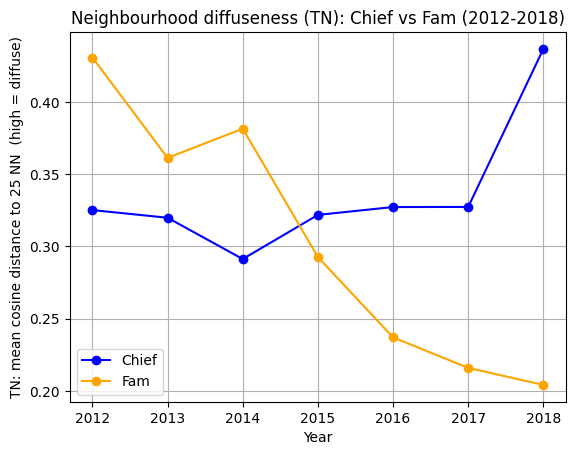

In [22]:
import matplotlib.pyplot as plt

# line chief vs fam for 2012 through 2018
# chief blue, fam orange

xs, ys = range(2012, 2019), [tn[y]["chief"] for y in range(2012, 2019)]
plt.plot(list(xs), ys, color='blue', marker='o', label='Chief')

xs, ys = range(2012, 2019), [tn[y]["fam"] for y in range(2012, 2019)]
plt.plot(list(xs), ys, color='orange', marker='o', label='Fam')

plt.xlabel('Year')
plt.ylabel('TN: mean cosine distance to 25 NN  (high = diffuse)')
plt.title('Neighbourhood diffuseness (TN): Chief vs Fam (2012-2018)')
plt.legend()
plt.grid(True)
plt.show()

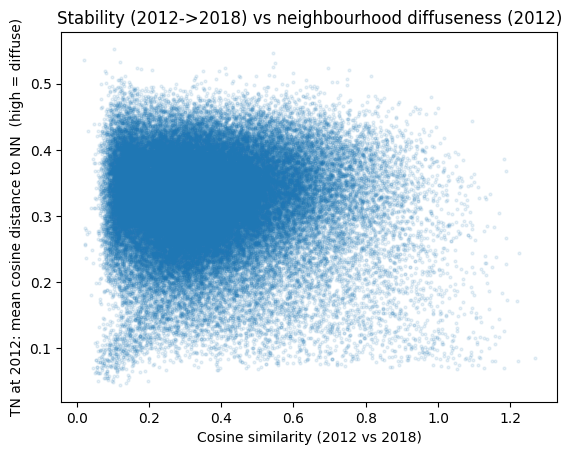

In [23]:
# scatter cos drift from 2012-2018 against 2012 TN
import matplotlib.pyplot as plt

drift_words, xs = sp.drift(2012, 2018)
ys = [tn[2012][w] for w in drift_words]

plt.scatter(xs, ys, s=4, alpha=0.1)
plt.xlabel('Cosine similarity (2012 vs 2018)')
plt.ylabel('TN at 2012: mean cosine distance to NN  (high = diffuse)')
plt.title('Stability (2012->2018) vs neighbourhood diffuseness (2012)')
plt.show()

In [24]:
# Per (word, year): step (1 - cos to next year), radius (TN), ratio, and chain
# (closest any of this year's neighbours sits to next year's self vector).
# Cached by driftcache; this is a parquet read.
df = sp.chaining()
df.head()

,word,year,step,radius,ratio,chain
0,a,2012,0.140802,0.495182,0.284343,0.514383
1,a,2013,0.085377,0.528414,0.161572,0.540107
2,a,2014,0.047293,0.552079,0.085663,0.549725
3,a,2015,0.037583,0.571775,0.065730,0.533679
4,a,2016,0.063184,0.573566,0.110161,0.586227


In [25]:
agg = sp.agg()

# Words with a 2012->2013 transition, kept in vector-vocab order so the
# xs/ys/keys lists below stay aligned.
_has_2012 = set(df.loc[df["year"] == 2012, "word"])
chain_words_2012 = [w for w in year_words[2012] if w in _has_2012]
agg.head()

,n_trans,mean_ratio,max_ratio,chain_first,chain_last,chain_mean,concentration,chain_rise,peak_year,chain_at_peak,chain_drop
word,,,,,,,,,,,
a,6,0.135014,0.284343,0.514383,0.550350,0.545745,0.351004,0.035967,2012,0.514383,0.031362
a'ight,6,1.741869,3.481939,0.152049,0.738465,0.533223,0.333161,0.586416,2012,0.152049,0.381174
a's,6,0.164428,0.281965,0.843717,0.829605,0.855292,0.285804,-0.014113,2012,0.843717,0.011575
aa,6,0.209451,0.395175,0.663255,0.721491,0.679870,0.314453,0.058236,2012,0.663255,0.016615
aa's,6,1.508367,1.826929,0.496008,0.500706,0.477823,0.201866,0.004698,2016,0.376418,0.101405


In [26]:
(agg["max_ratio"] >= 1).mean()

np.float64(0.5250521499226163)

In [27]:
xs = [tn[2012][w] for w in chain_words_2012]
ys = agg.loc[chain_words_2012, "concentration"].tolist()

Text(0.5, 1.0, 'TN Score (2012) vs Concentration')

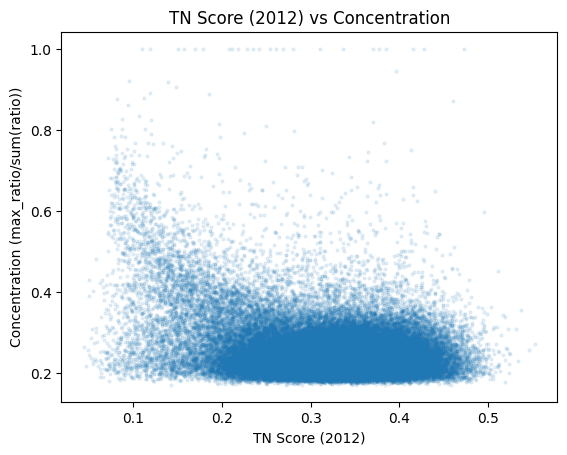

In [28]:
plt.scatter(xs, ys, s=4, alpha=0.1)
plt.xlabel("TN Score (2012)")
plt.ylabel("Concentration (max_ratio/sum(ratio))")
plt.title("TN Score (2012) vs Concentration")


In [29]:
from scipy.stats import spearmanr

print(spearmanr(xs, ys))

SignificanceResult(statistic=np.float64(-0.123479241978028), pvalue=np.float64(3.888132274563115e-244))


In [30]:
import plotly.express as px

keys = chain_words_2012

fig = px.scatter(x=xs, y=ys, hover_name=keys,
                 labels={'x': 'TN (2012)', 'y': 'Concentration'})

fig.update_traces(marker=dict(size=4,opacity=0.5),
                  selector=dict(mode='markers'))

fig.show()

In [31]:
import plotly.express as px

xs = [tn[2012][w] for w in chain_words_2012]
ys = agg.loc[chain_words_2012, "chain_rise"].tolist()

keys = chain_words_2012

fig = px.scatter(x=xs, y=ys, hover_name=keys,
                 labels={'x': 'TN (2012)', 'y': 'Chain Slope'})

fig.update_traces(marker=dict(size=4,opacity=0.5),
                  selector=dict(mode='markers'))

fig.show()

Text(0.5, 1.0, 'TN Score (2012) vs Chain Slope')

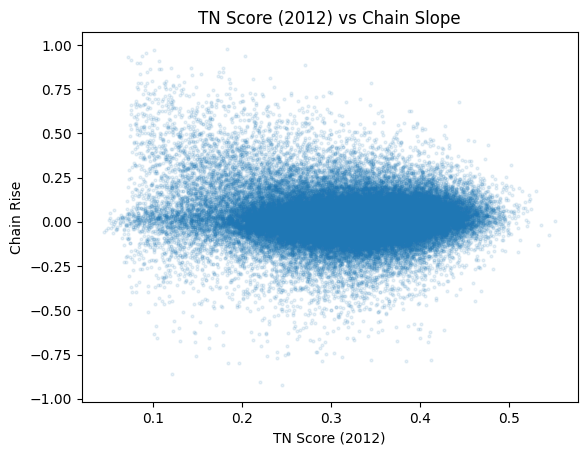

In [32]:
plt.scatter(xs, ys, s=4, alpha=0.1)
plt.xlabel("TN Score (2012)")
plt.ylabel("Chain Rise")
plt.title("TN Score (2012) vs Chain Slope")

### Correlation and Binning

In [33]:
from scipy.stats import spearmanr

print(spearmanr(xs, ys))

SignificanceResult(statistic=np.float64(0.00847548177901514), pvalue=np.float64(0.022508833430673756))


In [34]:
drift_words, drifts = sp.drift(2012, 2018)

drift_combined = [(w, d) for w, d in zip(drift_words, drifts)]

In [35]:
from collections import defaultdict

import numpy as np

keys = np.array(list(drift_combined))
values = np.array([d for w, d in drift_combined])

# 2. Define bin edges (e.g., bins: [0-3], [3-6], [6-9])
bins = np.array([np.percentile(values, 5*i) for i in range(1, 21)])

# 3. Digitize the values (returns indices specifying which bin each value belongs to)
bin_indices = np.digitize(values, bins)

# 4. Group dictionary keys by their assigned bin index
binned_dict = defaultdict(list)
for k, idx in zip(keys, bin_indices):
    binned_dict[int(idx)].append(k)

print(dict(binned_dict))

{5: [array(['to', '0.23027396'], dtype='<U45'), array(['and', '0.23849893'], dtype='<U45'), array(['you', '0.2308492'], dtype='<U45'), array(['that', '0.23584986'], dtype='<U45'), array(['still', '0.23683572'], dtype='<U45'), array(['though', '0.23022085'], dtype='<U45'), array(['gt', '0.23450124'], dtype='<U45'), array(['either', '0.2492699'], dtype='<U45'), array(['yet', '0.231143'], dtype='<U45'), array(['definitely', '0.2440055'], dtype='<U45'), array(['honestly', '0.23691964'], dtype='<U45'), array(['basically', '0.23492008'], dtype='<U45'), array(['gay', '0.23558891'], dtype='<U45'), array(['clearly', '0.22969371'], dtype='<U45'), array(['content', '0.2435726'], dtype='<U45'), array(['considering', '0.23689854'], dtype='<U45'), array(['suddenly', '0.24275196'], dtype='<U45'), array(['romney', '0.23695993'], dtype='<U45'), array(['bringing', '0.23953903'], dtype='<U45'), array(['therefore', '0.24501538'], dtype='<U45'), array(['atheists', '0.2445854'], dtype='<U45'), array(['chick

(array([3597., 3597., 3597., 3596., 3597., 3597., 3597., 3597., 3596.,
        3597., 3597., 3597., 3597., 3596., 3597., 3597., 3597., 3597.,
        3597.]),
 array([0.12281495, 0.15229864, 0.17979309, 0.20608577, 0.22967291,
        0.25189173, 0.27308464, 0.29446968, 0.31494126, 0.33575022,
        0.35716593, 0.3804372 , 0.4056963 , 0.43373883, 0.46546483,
        0.50148708, 0.54744059, 0.60938108, 0.70990574, 1.26777816]),
 <BarContainer object of 19 artists>)

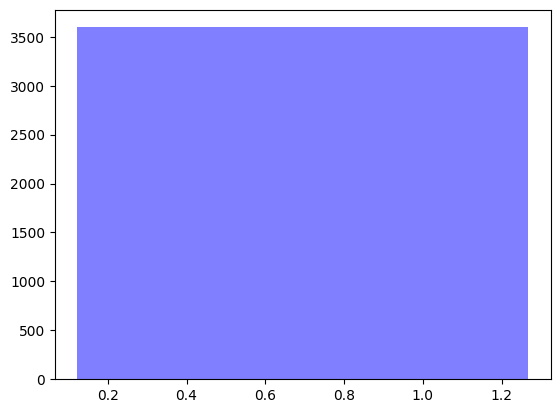

In [36]:
plt.hist(drifts, bins=bins, alpha=0.5, color='blue')

In [37]:
for bin in sorted(binned_dict.keys()):
    words = [item[0] for item in binned_dict[bin]]
    print(
        bin,
        spearmanr(
            [tn[2012][w] for w in words if w in agg.index],
            [agg.loc[w, "concentration"] for w in words if w in agg.index],
        ),
    )

0 SignificanceResult(statistic=np.float64(0.2959770769822556), pvalue=np.float64(1.209231103532292e-73))
1 SignificanceResult(statistic=np.float64(0.27588133072272336), pvalue=np.float64(7.65391706964754e-64))
2 SignificanceResult(statistic=np.float64(0.2278857842919092), pvalue=np.float64(1.3589493854588748e-43))
3 SignificanceResult(statistic=np.float64(0.17177063986132468), pvalue=np.float64(3.2030590196126475e-25))
4 SignificanceResult(statistic=np.float64(0.15304944552387909), pvalue=np.float64(2.7293074657116544e-20))
5 SignificanceResult(statistic=np.float64(0.049601210648679304), pvalue=np.float64(0.0029238742000985115))
6 SignificanceResult(statistic=np.float64(0.018577202174394406), pvalue=np.float64(0.2653321849939508))
7 SignificanceResult(statistic=np.float64(0.0008551321288134924), pvalue=np.float64(0.9591113861140678))
8 SignificanceResult(statistic=np.float64(-0.06257078900662924), pvalue=np.float64(0.000173301282328792))
9 SignificanceResult(statistic=np.float64(-0.099

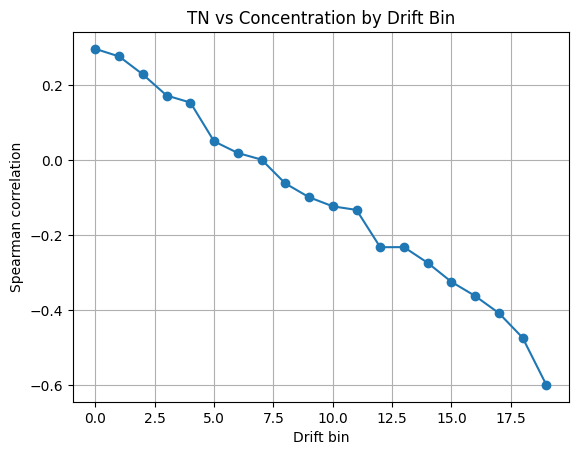

In [38]:
bin_keys = sorted(binned_dict.keys())
xs = bin_keys
ys = []

for bin_key in bin_keys:
    words = [item[0] for item in binned_dict[bin_key]]
    paired = [
        (tn[2012][word], agg.loc[word, "concentration"])
        for word in words
        if word in tn[2012] and word in agg.index
    ]

    if len(paired) >= 2:
        bin_xs, bin_ys = zip(*paired)
        ys.append(spearmanr(bin_xs, bin_ys).statistic)
    else:
        ys.append(np.nan)

plt.plot(xs, ys, marker="o")
plt.xlabel("Drift bin")
plt.ylabel("Spearman correlation")
plt.title("TN vs Concentration by Drift Bin")
plt.grid(True)
plt.show()

In [39]:
for bin in sorted(binned_dict.keys()):
    words = [item[0] for item in binned_dict[bin]]
    print(
        bin,
        spearmanr(
            [counts[2012][w] for w in words if w in counts[2012]],
            [agg.loc[w, "concentration"] for w in words if w in counts[2012]],
        ),
    )

0 SignificanceResult(statistic=nan, pvalue=nan)
1 SignificanceResult(statistic=nan, pvalue=nan)
2 SignificanceResult(statistic=nan, pvalue=nan)
3 SignificanceResult(statistic=nan, pvalue=nan)
4 SignificanceResult(statistic=nan, pvalue=nan)
5 SignificanceResult(statistic=nan, pvalue=nan)
6 SignificanceResult(statistic=nan, pvalue=nan)
7 SignificanceResult(statistic=nan, pvalue=nan)
8 SignificanceResult(statistic=nan, pvalue=nan)
9 SignificanceResult(statistic=nan, pvalue=nan)
10 SignificanceResult(statistic=nan, pvalue=nan)
11 SignificanceResult(statistic=nan, pvalue=nan)
12 SignificanceResult(statistic=nan, pvalue=nan)
13 SignificanceResult(statistic=nan, pvalue=nan)
14 SignificanceResult(statistic=nan, pvalue=nan)
15 SignificanceResult(statistic=nan, pvalue=nan)
16 SignificanceResult(statistic=nan, pvalue=nan)
17 SignificanceResult(statistic=nan, pvalue=nan)
18 SignificanceResult(statistic=nan, pvalue=nan)
19 SignificanceResult(statistic=nan, pvalue=nan)
20 SignificanceResult(statisti

In [40]:
df = sp.chaining()                  
g = df.groupby("word")
agg["conc_steps"] = g["step"].max() / g["step"].sum()

tot = {w: sum(d.values()) for w, d in counts.items()}
agg["log_freq"] = np.log10(agg.index.map(tot).astype(float))

sub = agg.dropna(subset=["conc_steps", "log_freq"])
spearmanr(sub["conc_steps"], sub["log_freq"])

SignificanceResult(statistic=np.float64(0.1392597734511512), pvalue=np.float64(0.0))

In [41]:
for bin in sorted(binned_dict.keys()):
    words = [item[0] for item in binned_dict[bin]]
    print(
        bin,
        spearmanr(
            [tn[2015][w] for w in words if w in agg.index and w in tn[2015]],
            [agg.loc[w, "conc_steps"] for w in words if w in agg.index and w in tn[2015]],
        ),
    )

0 SignificanceResult(statistic=np.float64(0.21076599694608691), pvalue=np.float64(2.1665501514826855e-37))
1 SignificanceResult(statistic=np.float64(0.16021794871734768), pvalue=np.float64(4.223092565419896e-22))
2 SignificanceResult(statistic=np.float64(0.16367335036589686), pvalue=np.float64(5.104203829857777e-23))
3 SignificanceResult(statistic=np.float64(0.1172722415862223), pvalue=np.float64(1.7221185630258424e-12))
4 SignificanceResult(statistic=np.float64(0.10545437512355078), pvalue=np.float64(2.3091658286257318e-10))
5 SignificanceResult(statistic=np.float64(0.03876173090795735), pvalue=np.float64(0.02008264378906855))
6 SignificanceResult(statistic=np.float64(0.04026797296886122), pvalue=np.float64(0.015740582707020254))
7 SignificanceResult(statistic=np.float64(0.04313555797055769), pvalue=np.float64(0.00968155922228684))
8 SignificanceResult(statistic=np.float64(-0.006684575974504504), pvalue=np.float64(0.688628646212382))
9 SignificanceResult(statistic=np.float64(-0.020783

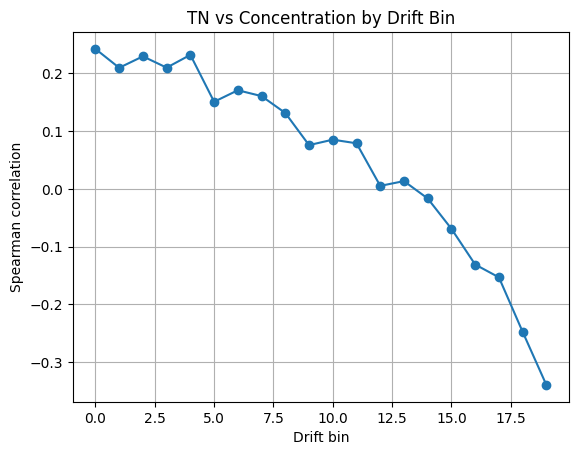

In [42]:
bin_keys = sorted(binned_dict.keys())
xs = bin_keys
ys = []

for bin_key in bin_keys:
    words = [item[0] for item in binned_dict[bin_key]]
    paired = [
        (tn[2012][word], agg.loc[word, "conc_steps"])
        for word in words
        if word in tn[2012] and word in agg.index
    ]

    if len(paired) >= 2:
        bin_xs, bin_ys = zip(*paired)
        ys.append(spearmanr(bin_xs, bin_ys).statistic)
    else:
        ys.append(np.nan)

plt.plot(xs, ys, marker="o")
plt.xlabel("Drift bin")
plt.ylabel("Spearman correlation")
plt.title("TN vs Concentration by Drift Bin")
plt.grid(True)
plt.show()

In [43]:
for b in sorted(binned_dict):
    ws = [w for w, _ in binned_dict[b] if w in agg.index]
    print(b, round(agg.loc[ws, "log_freq"].median(), 2), len(ws))

0 5.52 3597
1 5.14 3597
2 4.79 3597
3 4.5 3597
4 4.26 3596
5 4.06 3597
6 3.89 3597
7 3.77 3597
8 3.65 3597
9 3.61 3596
10 3.54 3597
11 3.51 3597
12 3.41 3597
13 3.38 3597
14 3.32 3596
15 3.27 3597
16 3.21 3597
17 3.15 3597
18 3.11 3595
19 3.02 3595
20 2.65 1


In [44]:
band = agg[(agg.log_freq > 4.0) & (agg.log_freq < 5.0)].index

In [45]:
band_drift = [(w, d) for w, d in drift_combined if w in band]

In [46]:
values = np.array([d for w, d in band_drift])
edges = np.array([np.percentile(values, 10*i) for i in range(1, 11)])   

idx = np.digitize(values, edges)

band_binned = defaultdict(list)
for (w, d), b in zip(band_drift, idx):
    band_binned[b].append((w, d))

In [47]:
print(dict(band_binned))

{np.int64(9): [('enhancement', np.float32(0.43042338)), ('redditenhancementsuite', np.float32(0.4806136)), ('sap', np.float32(0.6619153)), ('oag', np.float32(0.94322866)), ('hypnotoad', np.float32(0.5635965)), ('quickmeme', np.float32(0.6400663)), ('mitt', np.float32(0.40314388)), ('faqs', np.float32(0.6424648)), ('yolo', np.float32(0.47665393)), ('twinkie', np.float32(0.5050692)), ('swag', np.float32(0.5467359)), ('kony', np.float32(0.44533813)), ('gina', np.float32(0.64032507)), ('sopa', np.float32(0.62379646)), ('spacedicks', np.float32(0.47324938)), ('photogenic', np.float32(0.45157093)), ('moderators', np.float32(0.39540213)), ('rpg', np.float32(0.43242246)), ('shitredditsays', np.float32(0.66721344)), ('theists', np.float32(0.40269798)), ('pawn', np.float32(0.49735743)), ('derp', np.float32(0.39421225)), ('santorum', np.float32(0.49323797)), ('bane', np.float32(0.39003402)), ('wonka', np.float32(0.3929795)), ('transcriber', np.float32(0.90157485)), ('detailpage', np.float32(0.382

(array([1680., 1680., 1680., 1680., 1680., 1680., 1680., 1680., 1681.]),
 array([0.15232061, 0.1781507 , 0.1987811 , 0.21913669, 0.23879355,
        0.26075703, 0.28732023, 0.32181466, 0.37455687, 1.0948782 ]),
 <BarContainer object of 9 artists>)

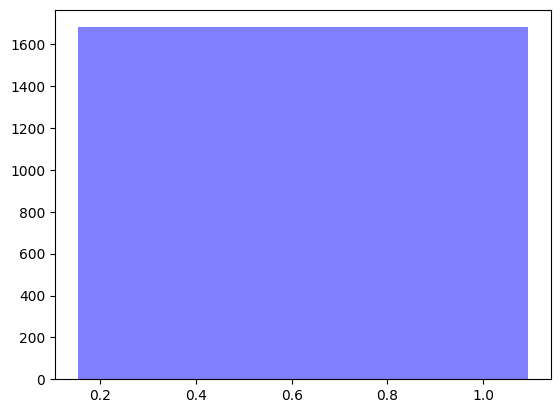

In [48]:
plt.hist(values, bins=edges, alpha=0.5, color='blue')

In [49]:
for bin in sorted(band_binned.keys()):
    words = [item[0] for item in band_binned[bin] if item[0] in band]
    print(
        bin,
        spearmanr(
            [tn[2015][w] for w in words if w in agg.index and w in tn[2012]],
            [agg.loc[w, "conc_steps"] for w in words if w in agg.index and w in tn[2012]],
        ),
    )

0 SignificanceResult(statistic=np.float64(0.12580280540300587), pvalue=np.float64(2.2834039087450382e-07))
1 SignificanceResult(statistic=np.float64(0.12420431805670859), pvalue=np.float64(3.2755825822709746e-07))
2 SignificanceResult(statistic=np.float64(0.06995889717526524), pvalue=np.float64(0.004119766982797258))
3 SignificanceResult(statistic=np.float64(0.030269011777366902), pvalue=np.float64(0.21496763128507054))
4 SignificanceResult(statistic=np.float64(0.03939157918923327), pvalue=np.float64(0.106527646996191))
5 SignificanceResult(statistic=np.float64(-0.00026313481140385485), pvalue=np.float64(0.9914011327809166))
6 SignificanceResult(statistic=np.float64(0.009190750239677057), pvalue=np.float64(0.7065926189764792))
7 SignificanceResult(statistic=np.float64(-0.011085514999249571), pvalue=np.float64(0.6497952386777487))
8 SignificanceResult(statistic=np.float64(-0.026477088175746115), pvalue=np.float64(0.2780899628095231))
9 SignificanceResult(statistic=np.float64(0.018356865

Text(0.5, 1.0, 'TN vs Concentration by Drift Bin (log_freq 4-5)')

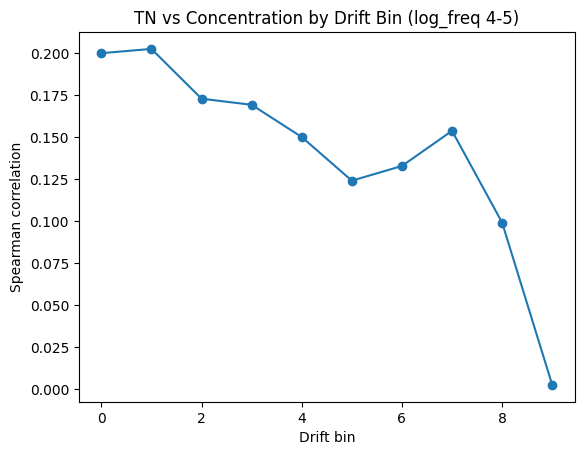

In [50]:
xs = sorted(band_binned.keys())
ys = []

for bin_key in xs:
    words = [item[0] for item in band_binned[bin_key] if item[0] in band]
    paired = [
        (tn[2012][word], agg.loc[word, "conc_steps"])
        for word in words
        if word in tn[2012] and word in agg.index
    ]

    if len(paired) >= 2:
        bin_xs, bin_ys = zip(*paired)
        ys.append(spearmanr(bin_xs, bin_ys).statistic)
    else:
        ys.append(np.nan)
        
plt.plot(xs, ys, marker="o")
plt.xlabel("Drift bin")
plt.ylabel("Spearman correlation")
plt.title("TN vs Concentration by Drift Bin (log_freq 4-5)")

In [51]:
for b in sorted(band_binned.keys()):
    ws = [w for w, _ in band_binned[b] if w in agg.index]
    print(b, round(agg.loc[ws, "log_freq"].median(), 2), len(ws))

0 4.76 1681
1 4.65 1680
2 4.56 1680
3 4.48 1680
4 4.41 1680
5 4.34 1680
6 4.27 1680
7 4.22 1680
8 4.2 1680
9 4.17 1680
10 4.36 1
